In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib.colors import BoundaryNorm
from pathlib import Path

import sys
module_path = "../bin"
sys.path.insert(0,module_path)

import um_utils_plotting as umplt
import um_utils as um
from geometry_fix import apply_geometry_collection_fix

apply_geometry_collection_fix()

um.WarningSuppress()

MEANS_DIR = Path("../Data/Models/Monthly_Means")
PROXY_DIR = Path("/Users/ajw1g19/Library/CloudStorage/OneDrive-UniversityofSouthampton/INSPIRE DTP/Projects/Palaeo-Proxies")

In [2]:
#------------------------------------------------------------
# PNAS Figure Specification
#------------------------------------------------------------

PNAS_WIDTH = {1: 3.42, 1.5: 4.5, 2: 7.0}      # inches
PNAS_MAX_HEIGHT = 9.0

def pnas_figsize(cols, height):
    """Figure size in inches for a PNAS column count and chosen height."""
    if height > PNAS_MAX_HEIGHT:
        raise ValueError(f"height {height}in exceeds PNAS maximum of {PNAS_MAX_HEIGHT}in")
    return (PNAS_WIDTH[cols], height)

FS = {              # font sizes
    "panel": 8,     # (a), (b) ... panel letters
    "title": 8,     # panel titles
    "label": 7,     # axis and colorbar labels
    "tick": 6,      # tick labels
    "legend": 6,    # legend
    "annot": 6,     # Axes annotations
}

LW = {              # line widths 
    "spine": 0.8,   # axes spines
    "coast": 0.5,   # map coastlines
    "border": 0.3,  # map borders 
    "grid": 0.2,    # gridlines
    "contour": 0.1, # contours
    "data": 0.8,    # scatter point edgewidths
}

MS = {              # marker sizes
    "proxy": 10,    # scatter points
    "legend": 4,    # legend markers
}

plt.rcParams.update(plt.rcParamsDefault)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [3]:
#------------------------------------------------------------
# Import Surface Fractions
#------------------------------------------------------------

MH_sfrac = um.importUMData(MEANS_DIR / "MH_monthly_means.nc")["surfacefrac"] * 100
PI_sfrac = um.importUMData(MEANS_DIR / "PI_monthly_means.nc")["surfacefrac"] * 100

LON, LAT = np.meshgrid(MH_sfrac.longitude, MH_sfrac.latitude)

#------------------------------------------------------------
# Group Surface Tiles into Plant Functional Types
#------------------------------------------------------------

PFTS = {
    "Evergreen Forest": [1, 2, 4, 12],
    "Summergreen Forest": [0, 3, 11],
    "Open Vegetation (Grassland)": [5, 6, 7, 8, 9, 10],
}

def group_sfrac(sfrac, tiles):
    return sfrac[:, tiles].sum(dim="surface_tiles", min_count=1).squeeze().mean(dim="time")

sfrac_anom = {pft: group_sfrac(MH_sfrac, tiles) - group_sfrac(PI_sfrac, tiles)
              for pft, tiles in PFTS.items()}

#------------------------------------------------------------
# Import Dawson Vegetation Reconstruction
#------------------------------------------------------------

dawson_vars = ["ET", "ST", "OL"]

df200, df6k = um.importRevealsYrs(PROXY_DIR / "Dawson" / "REVEALS_LCT_gridded.csv", [500, 6000])
dawson_lon, dawson_lat = df200["x"], df200["y"]

dawson_anom = {pft: (df6k[var].values - df200[var].values) * 100
               for pft, var in zip(PFTS, dawson_vars)}


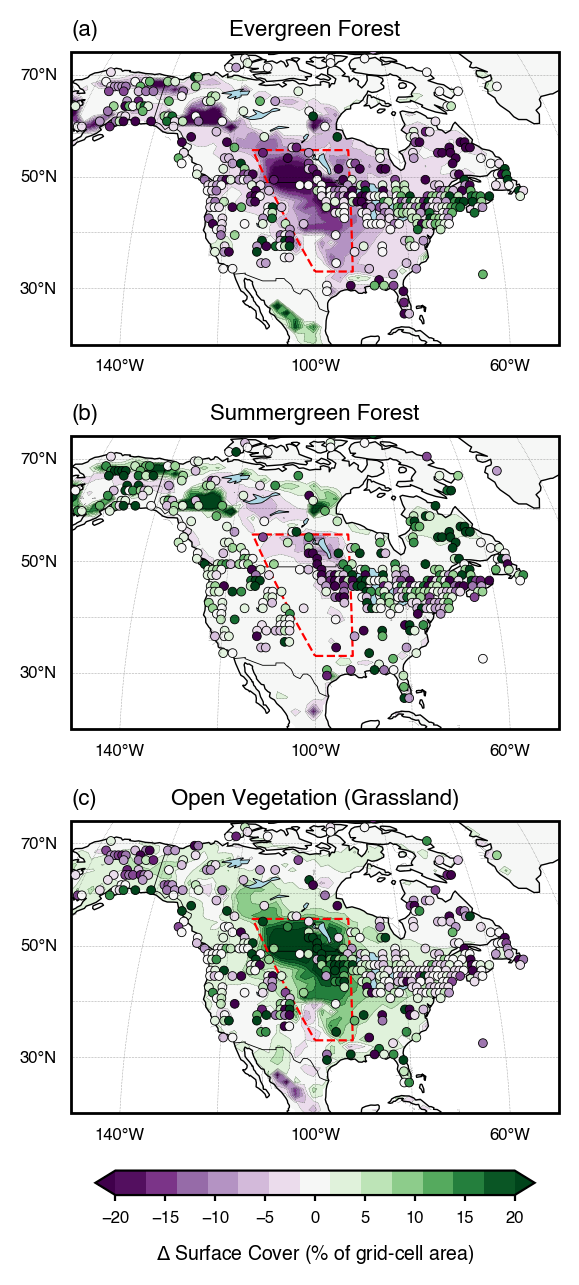

In [4]:
#------------------------------------------------------------
# Colorbar Helper
#------------------------------------------------------------

def cbar_axes_under(fig, axes, width=0.9, height=0.018, pad=0.05):
    fig.canvas.draw()
    boxes = [ax.get_position(original=False) for ax in axes]

    x0 = min(b.x0 for b in boxes)
    x1 = max(b.x1 for b in boxes)
    y0 = min(b.y0 for b in boxes)

    w = (x1 - x0) * width
    return fig.add_axes([0.5 * (x0 + x1) - w / 2, y0 - pad, w, height])

#------------------------------------------------------------
# Properties for Maps
#------------------------------------------------------------

fig = plt.figure(figsize=pnas_figsize(1, 6.8), dpi=200)
gs = GridSpec(3, 1)

lims, proj = [-150, -50, 20, 75], ccrs.Robinson(central_longitude=-100)
GP_region = umplt.umRegion("GP")

v = 20
cmap = cm.PRGn
levs = np.linspace(-v, v, 14)
norm = BoundaryNorm(levs, cmap.N, extend="both")
cbar_ticks = np.linspace(-v, v, 9)
cbar_label = r"$\Delta$ Surface Cover (% of grid-cell area)"
labels = ["a", "b", "c"]

CBAR_BOTTOM = 0.13      # figure fraction reserved for the colorbar

RASTER_Z = 10

#------------------------------------------------------------
# Plotting Maps
#------------------------------------------------------------

map_axes = []

for i, (pft, anom) in enumerate(sfrac_anom.items()):
    ax = plt.subplot(gs[i], projection=proj)
    ax.set_rasterization_zorder(RASTER_Z)
    umplt.plotBaseMap(ax, lims, ocean=True, oceancol="white", lakes=True, bordercol="black",
                      coastlw=LW["coast"], borderlw=LW["border"])
    gl, glines = umplt.plotGrid(ax, xlabeledlines=[-60, -100, -140], ylabeledlines=[30, 50, 70],
                   xlines=[-40, -80, -120, -160], ylines=[40, 60],
                   labelsize=FS["tick"], lw=LW["grid"], ls="dotted", alph=0.6)
    gl.set_zorder(RASTER_Z + 1)
    glines.set_zorder(RASTER_Z - 1)

    cf = ax.contourf(LON, LAT, anom.data, extend="both", cmap=cmap, levels=levs,
                     transform=ccrs.PlateCarree(), transform_first=True, zorder=0)
    cs = ax.contour(LON, LAT, anom.data, colors="black", levels=levs, linestyles="dashed",
               linewidths=LW["contour"], transform=ccrs.PlateCarree(), transform_first=True, zorder=1)

    line_kws = {"color": "red", "linestyle": "dashed", "linewidth": LW["data"], "zorder": 3}
    gp = GP_region.plot(ax=ax, line_kws=line_kws, add_coastlines=False, add_label=False)

    # Proxy reconstructions on top
    sc = ax.scatter(dawson_lon, dawson_lat, c=dawson_anom[pft], s=MS["proxy"], marker="o",
               cmap=cmap, norm=norm, edgecolors="black", linewidths=LW["border"],
               transform=ccrs.PlateCarree(), zorder=5)

    ax.set_title(f"({labels[i]})", loc="left", fontsize=FS["panel"], pad=6, zorder=RASTER_Z+1)
    ax.set_title(pft, fontsize=FS["title"], pad=6, zorder=RASTER_Z+1)

    map_axes.append(ax)

#------------------------------------------------------------
# Colorbar and Final Adjustments
#------------------------------------------------------------

plt.tight_layout(rect=[0, CBAR_BOTTOM, 1, 1])

cax = cbar_axes_under(fig, map_axes, width=0.9, height=0.018, pad=0.06)
cbar = fig.colorbar(cf, cax=cax, orientation="horizontal", ticks=cbar_ticks,
                    format=mticker.StrMethodFormatter("{x:g}"))
cbar.ax.tick_params(labelsize=FS["tick"], length=2)
cbar.set_label(cbar_label, size=FS["label"], labelpad=6)

plt.show()
